# Домашнее задание 3. Детекция объектов

Сыграем в квиддич? Или лучше в карты?

В этом дз вам предстоит написать практически с нуля архитектуру для детекции, а также воспользоваться готовым решением. На выбор даётся два датасета, отличаются они только картинками. Форматы, баллы - все одинаково.

Первый вариант это датасет по кадрам игры в квиддич из Гарри Поттера. Если вы забыли правила, то нажмите [сюда](https://harrypotter.fandom.com/ru/wiki/%D0%9A%D0%B2%D0%B8%D0%B4%D0%B4%D0%B8%D1%87). Вы научитесь искать и выделять на фотографиях бладжеры, квоффл и снитч.

Второй вариант это датасет с игральными картами. Если вы забыли что такое карты, то нажмите [сюда](https://ru.wikipedia.org/wiki/%D0%98%D0%B3%D1%80%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D0%B5_%D0%BA%D0%B0%D1%80%D1%82%D1%8B). Вы научитесь искать и выделять на фотографиях несколько типов карт.

Оба варианта содержат около 300 картинок, данные хранятся в xml в формате PascalVOC. Есть малые отличия, но ничего страшного.


Если с самописным детектором совсем не получается, то можно после создания датасетов перейти к концу, где обучается готовый, с ним будет проще :)

## Данные

Скачайте один из датасетов на свой вкус и начните работу с ним.
Разметка находится в xmls папке, картинки в images.

In [1]:
# Harry Potter -- uncomment
#!wget https://github.com/markblumenau/hw3_iad_dl/raw/main/harry/data.zip

# Cards -- uncomment
#!wget https://github.com/markblumenau/hw3_iad_dl/raw/main/cards/data.zip



#!unzip -q data.zip

# Задача 1. 0.5 балла.

Ниже написан код для стандартного Dataset из библиотеки pytorch. Dataset требует реализации `__getitem__` и `__len__` методов. Далее эти методы будут использованы для формирования батчей для обучения. Поскольку читать придется из xml файлов, нужно перед этим дописать функцию get_xml_data, чтобы по названию картинки подтягивать аннотации.

In [2]:
#!pip install -q albumentations

In [3]:
import torch
from xml.etree import ElementTree as ET
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from pathlib import Path
import glob
import numpy as np
from PIL import Image
import torchvision
from torchvision.models import ResNet50_Weights
from tqdm.notebook import tqdm
from torch import nn
import shutil
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch.nn.functional as F
import os
COLAB = False

Функции можно и нужно передать некий class_dict. Он есть и при инициализации датасета ниже. С его помощью можно название класса превратить в int. Далее подразумевается, что класс идёт как int.

In [4]:
def get_xml_data(image_name, root, class_dict, xml_prefix="/xmls/"):
    # get smth like ZZZ/YYY/XXXXXX.jpg -> XXXXXX
    if COLAB:
        filename = image_name.split("/")[-1].split(".")[0]
        tree = ET.parse(str(root) + xml_prefix + filename + ".xml")
    else:
        filename = Path(image_name).stem
        xml_path = Path(root) / "xmls" / f"{filename}.xml"
        tree = ET.parse(xml_path)
    treeroot = tree.getroot()
    # read xml

    # iterate over bboxes
    bboxes = []
    for member in treeroot.findall("object"):

        bndbox = member.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)
        # you need: xmin ymin xmax ymax, class in dict

        class_name = member.find("name").text
        class_id = class_dict[class_name]

        res =  [xmin, ymin, xmax, ymax, class_id]
        bboxes.append(res)

    return bboxes

In [5]:
class PascalDataset(torch.utils.data.Dataset):
    def __init__(self, *, transform, root="dataset", train=True, seed=42):
        self.root = Path(root)
        self.transform = transform

        assert self.root.is_dir(), f"No data at `{root}`"

        self.filenames = np.array(glob.glob(root + "/images/*"))
        with open(str(self.root) + "/class_dict", "r") as f:
            self.class_dict = eval(f.readline())

        self.class_dict_inv = {v: k for k, v in self.class_dict.items()}

        np.random.seed(seed)
        permutation = np.random.permutation(len(self.filenames))

        # Train/test split
        if train:
            self.filenames = self.filenames[
                permutation[: int(len(self.filenames) * 0.9)]
            ].tolist()
        else:
            self.filenames = self.filenames[
                permutation[int(len(self.filenames) * 0.9) :]
            ].tolist()

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        image = np.array(Image.open(fname).convert("RGB"))
        bboxes = get_xml_data(fname, self.root, self.class_dict)


        return self.transform(image=image, bboxes=bboxes)

    def __get_raw_item__(self, idx):
        fname = self.filenames[idx]
        return fname, get_xml_data(fname, self.root, self.class_dict)

    def __len__(self):
        return len(self.filenames)

Ниже определяем стандартные нормализации и приведение размера к 512x512.


In [6]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=dict(format="pascal_voc", min_visibility=0.3),
)

test_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=dict(format="pascal_voc", min_visibility=0.5),
)

In [7]:
train_ds = PascalDataset(root="./data/data/", transform=train_transform, train=True)
test_ds = PascalDataset(root="./data/data/", transform=test_transform, train=False)

# Задача 2. 1 балл.

Теперь, когда мы загрузили данные, хорошо бы посмотреть на них, прежде чем обучать какие-либо модели. Напишите функцию `visualize`, которая принимает списки изображений и прямоугольников в качестве входных данных и рисует эти прямоугольники на изображениях.

В датасете есть class_dict_inv, который позволит вам сделать обратное преобразование: int, содержащий класс, в строку с названием.


Полезные функции:
* [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) -- легко создавать несколько изображений в одной pyplot figure
* [ax.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) -- отображение графиков (не забудьте откатить нормализацию)
* [ax.text](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html), [patches.Rectangle](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html) -- для рисования прямоугольников и текста с аннотацией

In [ ]:
def visualize(images, bboxes):
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)

    fig, axes = plt.subplots(
        2, len(images) // 2 + len(images) % 2, figsize=(10, 8), dpi=100
    )

    for i, ax in enumerate(axes.reshape(-1)):

        ax.axis(False)

        if i >= len(bboxes):
            break
        
        permute_image = images[i].permute(1, 2, 0).numpy()
        reverse_normalize = (permute_image * std) + mean
        # Вот тут нужно выполнить permute (вспомните где у torch каналы, а где они у matplotlib)
        # И откатить нормализацию (просто обратное преобразование)
        # Имена и количества классов можно подтянуть из датасета через train_ds.class_dict_inv

        ax.imshow(reverse_normalize)

        for bbox in bboxes[i]:
            ax.add_patch(
                Rectangle(
                    (bbox[0], bbox[1]),
                    bbox[2] - bbox[0],
                    bbox[3] - bbox[1],
                    fill=False,
                    color="red",
                    linewidth=2,
                )
            )
            ax.text(
                bbox[0],
                bbox[1] - 5,
                train_ds.class_dict_inv[bbox[4]],
                color="red",
                fontsize=12,
            )

    fig.tight_layout()
    plt.show()

У вас должно получиться что-то похожее на изображения для датасета с масками:

![image](https://gcdnb.pbrd.co/images/n8BnhhfCgYnQ.png)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9999999964237213].


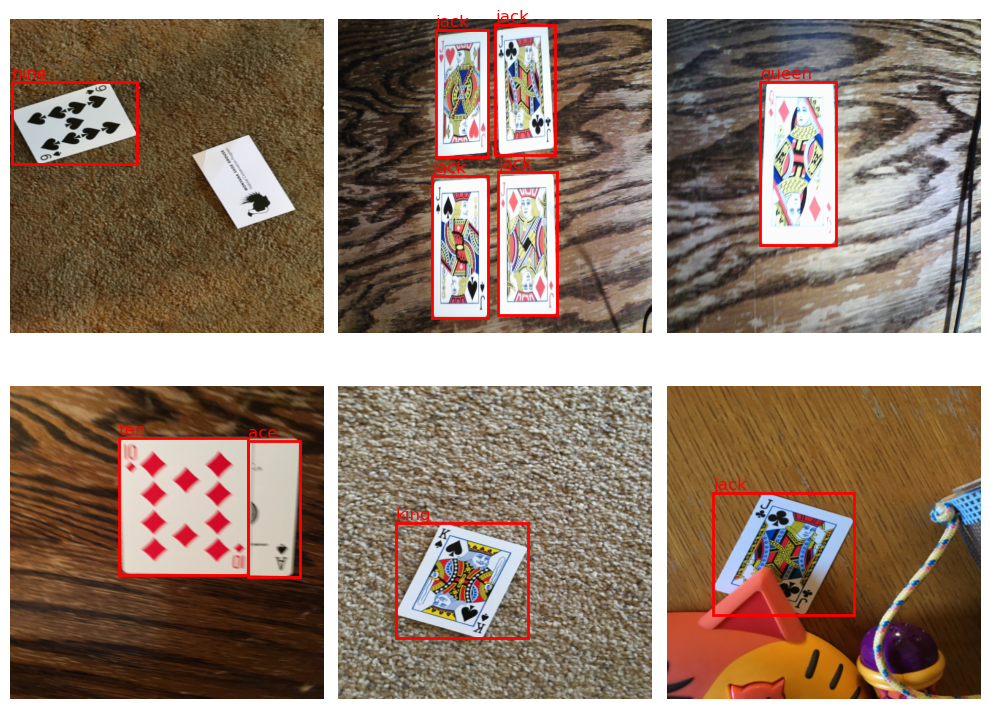

In [9]:
out = [train_ds[i] for i in range(6)]
visualize([o["image"] for o in out], [o["bboxes"] for o in out])

# Задача 3. 3 балла.
## YOLO-like детектор

Сейчас нам предстоить реализовать детектор, похожий на YOLO. Это один из самых простых детекторов с точки зрения реализации. YOLO описан в статье: [You Only Look Once: Unified, Real-Time Object Detection](https://arxiv.org/abs/1506.02640). Здесь мы его немного изменим и упростим. Будем использовать ResNet для извлечения признаков. На выходе мы будем получать карту признаков размера 16x16.

We convert lists of bounding boxes to the target downsampled grid. For this we

* compute centers of bounding boxes ($c_x, c_y$)
* change center coordinates (offset from the top left corner for each corresponding grid cell on a small grid)
* normalize box height and with to $[0, 1]$
* fill the target grid with values

## Задача 3.1. 1 балл.

Первым делом нам нужно реализовать collate function. Это функция позволит нам кастомизировать, как именно батч конструируется из примеров (смотрите [pytorch docs](https://pytorch.org/docs/stable/data.html#dataloader-collate-fn) для деталей).

Это функция должна принять на вход лист прямоугольников и сгенерировать тензор размера Bx16x16x6. Первая размерность - это количество примеров в батче. Далее идут две пространственные размерности, это сетка 16 на 16. 

В каналах у нас будут записаны:
* Сдвиги центра bbox относительно начала клеточки (клеточка это "пиксель" на изображении 16 на 16 на выходе сети). Записаны эти сдвиги будут в клеточку, к которой относятся. 2 канала (X, Y)
* Нормализованные ширина и высота bbox. 2 канала (W, H)
* Confidence сетки. Им мы будем пользоваться, чтобы фильтровать уверенность сетки в наличии bbox в данной клетке. Таргет содержит 1 там, где bbox есть, и 0 иначе. 1 канал
* Класс детекции (тот самый int, полученный из строки с названием)

In [10]:
def collate_fn(batch, downsample=32):
    imgs, batch_boxes = map(list, (zip(*[(b["image"], b["bboxes"]) for b in batch])))

    imgs = torch.stack(imgs)
    b, _, h, w = imgs.shape

    target = imgs.new_zeros(b, 6, h // downsample, w // downsample)

    # Add sample index to targets
    for i, boxes in enumerate(batch_boxes):
        xmin, ymin, xmax, ymax, classes = map(
            torch.squeeze, torch.split(imgs.new_tensor(boxes), 1, dim=-1)
        )

        # Нормализуйте ширину и высоту, поделив на ширину и высоту исходного изображения
        x_cell = downsample  # размер клетки по X в пикс
        y_cell = downsample  # размер клетки по Y в пикс
        w_box = (xmax - xmin) / w  # ширина бокса отнормированная
        h_box = (ymax - ymin) / h  # высота бокса отнормированная

        # Посчитайте координаты центра и сдвиги
        cx = (xmin + xmax) / 2  # (координаты центра в исходных координатах)
        cy = (ymin + ymax) / 2 #
        cx_idx = (cx / x_cell).long()  # (посчитайте индекс центра на карте признаков размера 16x16. Это будут как раз координаты пикселя, куда мы запишем параметры коробки)
        cy_idx = (cy / y_cell).long()  #

        cx_box = (cx - cx_idx * x_cell) / x_cell  # (посчитайте сдивиги относительно cx_idx)
        cy_box = (cy - cy_idx * y_cell) / y_cell  #

        target[i, :, cy_idx, cx_idx] = torch.stack(
            [cx_box, cy_box, w_box, h_box, torch.ones_like(cx_box), classes]
        )

    return {"image": imgs, "target": target}

Ниже вы можете увидеть пример, как выглядит решетка размера 16 на 16 на исходном изображении:

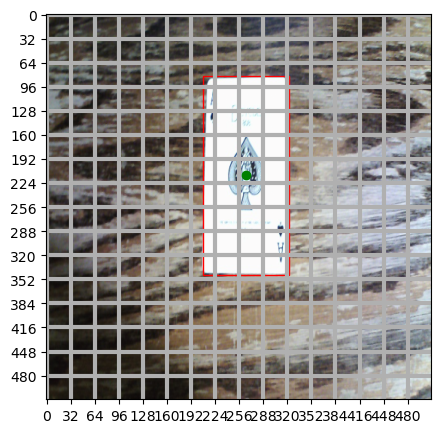

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
i = 20

img = train_ds[i]["image"].permute(1, 2, 0) * torch.tensor(std).view(
    1, 1, -1
) + torch.tensor(mean).view(1, 1, -1)
bboxes = torch.tensor(train_ds[i]["bboxes"])

ax.imshow(img)
loc = plt.matplotlib.ticker.MultipleLocator(base=32)
ax.xaxis.set_major_locator(loc)
ax.yaxis.set_major_locator(loc)
ax.grid(which="major", axis="both", linestyle="-", linewidth=3)

for bbox in bboxes:
    xmin, ymin, xmax, ymax = bbox[:-1]
    w = xmax - xmin
    h = ymax - ymin
    with_mask = bbox[-1]
    ax.add_patch(Rectangle((xmin, ymin), w, h, fill=False, color="red"))

cx = (bboxes[:, 0] + bboxes[:, 2]) / 2
cy = (bboxes[:, 1] + bboxes[:, 3]) / 2

ax.scatter(cx, cy, color="green", marker="o")

plt.show()

## Задача 3.2. 0.5 балла.

Выход нашей сетки будет несколько больше, чем Bx16x16x6. Почему? 

Мы решаем задачу, где классов больше одного. Вспомним прошлое дз: target был одним числом, но выход сетки содержал длинный-длинный вектор, из которого мы получали вероятность принадлежности к тому или иному классу. Здесь то же самое, но как бы в двумерии: у каждой клеточки из этих 16*16 будет свой вектор длины C, который мы будем использовать для определения класса.

Реализуйте обратное относительно collate_fn преобразования, чтобы декодировать выход нейронной сети. Применив функцию decode_prediction к выходу collate function вы должны получить изначальный набор прямоугольников с корректными размерами и координатами, а также классами. Применив к выходу нейросети мы тоже должны получить набор прямоугольников и тоже с корректными классами. 

То есть, нужно проделать операции из collate_fn в обратную сторону, но учесть, что у неройнки выход будет чуть длиннее, и там мы должны брать argmax для определения класса.

Hint: в target classes идут в конце. В нейронке они тоже будут в конце, но их будет больше 1. Можно проверять число каналов пришедшего объекта, если оно 6, то перед нами target и надо брать значение, которое записано в клеточке. Иначе (каналов больше 6) перед нами выход нейронки, и надо брать самый вероятный из них.

In [12]:
def decode_prediction(pred, upsample=32, threshold=0.7):
    b, c, h, w = pred.shape
    img_w, img_h = w * upsample, h * upsample
    
    dx = pred[:, 0, :, :]
    dy = pred[:, 1, :, :]
    dw = pred[:, 2, :, :]
    dh = pred[:, 3, :, :]
    conf = pred[:, 4, :, :]
    
    if c == 6:
        cls = pred[:, 5, :, :].float()
    else:
        cls = pred[:, 5:, :, :].argmax(dim=1).float()

    y_idx = torch.arange(h).view(1, h, 1).expand(b, h, w)
    x_idx = torch.arange(w).view(1, 1, w).expand(b, h, w)

    cx = (x_idx + dx) * upsample
    cy = (y_idx + dy) * upsample

    w_abs = dw * img_w
    h_abs = dh * img_h

    xmin = (cx - w_abs / 2).clamp(0, img_w)
    ymin = (cy - h_abs / 2).clamp(0, img_h)
    xmax = (cx + w_abs / 2).clamp(0, img_w)
    ymax = (cy + h_abs / 2).clamp(0, img_h)

    mask = conf > threshold

    batch_boxes = []
    for i in range(b):
        indices = mask[i].nonzero(as_tuple=False)
        if indices.size(0) == 0:
            batch_boxes.append([])
            continue

        y_inds = indices[:, 0]
        x_inds = indices[:, 1]

        # Сортируем по conf пока он ещё доступен отдельно
        conf_vals = conf[i, y_inds, x_inds]
        sort_idx = conf_vals.argsort(descending=True)
        y_inds = y_inds[sort_idx]
        x_inds = x_inds[sort_idx]

        boxes = torch.stack([
            xmin[i, y_inds, x_inds],
            ymin[i, y_inds, x_inds],
            xmax[i, y_inds, x_inds],
            ymax[i, y_inds, x_inds],
            cls[i, y_inds, x_inds],    # индекс 4 = class_id
        ], dim=1)

        batch_boxes.append(boxes.cpu().numpy().tolist())

    return batch_boxes

## Задача 3.3. 1 балл.
Реализуйте модель. Первым делом примените первые 4 блока (до layer4 включительно) ResNet50. Далее добавьте несколько блоков (Conv2D, BatchNorm2D, ReLU). Постепенно уменьшайте количество каналов до 5+C, а размер изображения до 16 на 16. Например, 2048 -> 512 -> 128 -> 32 -> 5+C, где С - количество классов в вашем датасете. Размер ядра при этом 3, паддинг 1. Но вариантов много, попробуйте разные! **Последним слоем обязательно должна быть свертка.** Так как все значения, которые мы предсказываем, находятся в отрезке от 0 до 1 (благодаря нормировке с клеточками), мы после финальной свертки еще применим сигмоиду. Для классов в такой постановке это не навредит.

Если будете фантазировать, то для получения правильного размера изображения после сети не стесняйтесь применять слои с фильтрами больше 3.

In [ ]:
C = 6 # Количество классов в вашем датасете


class Detector(nn.Module):
    def __init__(self):
        super().__init__()
        model = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(model.children())[:-2])
        # self.backbone = nn.Sequential(
        #     model.conv1,
        #     model.bn1,
        #     model.relu,
        #     model.maxpool,
        #     model.layer1,
        #     model.layer2,
        #     model.layer3,
        #     model.layer4,
        # )

        self.head = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),

            nn.Conv2d(1024, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 32, kernel_size=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, C + 5, kernel_size=1),
        )
        

    def forward(self, img):
        x = self.backbone(img)
        x = self.head(x)
        x = torch.sigmoid(x)
        return x

## Задача 3.4. 0.5 балла.

Реализуйте функцию потерь.

Для этого:
* Сделайте маску, которая будет говорить о положении детектируемых объектов. Её нужно использовать с помощью masked_select (см. доки PyTorch)
* Лосс похож на оригинальный для Yolo V1 и состоит из 4 частей (reduction='sum' для всех)
    - localization loss - Мы берем MSE по координатам бокса там, где есть детектируемый объект
    - box_loss - MSE от корней ширины и высоты bbox там, где есть детектируемый объект
    - classification_loss - Если детектируемый объект есть, то его кросс-энтропия по его классу
    - confidence_loss - Бинарная кросс-энтропия факта наличия объекта ДЛЯ ВСЕХ пикселей. Делается отдельно для детектируемых объектов (вес 1) и для недетектируемых (вес 0.1 например, поскольку их гораздо больше, но можно экспериментировать)


* Ниже есть assert. Если вы экспериментируете с лоссом, он не будет проходить, не обращайте на него внимание. Если будете делать описанное выше, то учтите reduction. Бинарная кросс-энтропия вызывается через BCELoss. Параметр C используется для задачи числа классов. assert написан для 3 классов, в задаче с картами их 6. Подумайте как зависит индексация от параметра C и используйте его.

In [14]:
def special_loss(pred, target, check=False, C=C):
    
    obj_mask = target[:, 4, :, :] == 1  # [B, 16, 16]
    obj_mask_2ch = obj_mask.unsqueeze(1).expand(-1, 2, -1, -1)  # [B, 2, 16, 16]

    # --- xy и wh ---
    pred_xy   = pred[:, :2, :, :]
    target_xy = target[:, :2, :, :]
    pred_wh   = pred[:, 2:4, :, :]
    target_wh = target[:, 2:4, :, :]

    localization_loss = F.mse_loss(
        pred_xy[obj_mask_2ch], target_xy[obj_mask_2ch], reduction='sum'
    )
    box_loss = F.mse_loss(
        pred_wh[obj_mask_2ch].sqrt(), target_wh[obj_mask_2ch].sqrt(), reduction='sum'
    )

    # --- classification: pred даёт C каналов, target — один integer id ---
    pred_cls    = pred[:, 5:5+C, :, :]          # [B, C, 16, 16]
    target_cls  = target[:, 5, :, :].long()      # [B, 16, 16]

    pred_cls_obj   = pred_cls.permute(0, 2, 3, 1)[obj_mask]   # [N, C]
    target_cls_obj = target_cls[obj_mask]                      # [N]

    classification_loss = F.cross_entropy(
        pred_cls_obj, target_cls_obj, reduction='sum'
    )

    # --- confidence ---
    pred_conf   = pred[:, 4, :, :]
    target_conf = target[:, 4, :, :]

    bce = F.binary_cross_entropy(
        pred_conf.clamp(1e-7, 1 - 1e-7),
        target_conf,
        reduction='none'
    )  # [B, 16, 16]

    confidence_loss = (
        bce[obj_mask].sum()
        + 0.1 * bce[~obj_mask].sum()
    )

    if not check:
        return localization_loss + box_loss + classification_loss + confidence_loss
    else:
        return localization_loss, box_loss, classification_loss, confidence_loss

In [ ]:
# localization box classification confidence - возвращаются в таком порядке, можно сравнить
assert special_loss(torch.zeros((10, 8, 16, 16)), torch.ones((10, 8, 16, 16)), check=True, C=3) == (torch.tensor(5120.), torch.tensor(5120.), torch.tensor(2812.4465), torch.tensor(256000.))

# Задача 4. 2 балла.

Обучите вашу модель (написав цикл обучения), и покажите что она работает (скорее всего, объекты найдутся на 1-2 картинках).

In [ ]:
loader = torch.utils.data.DataLoader(train_ds, 10, collate_fn=collate_fn)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(21)
EPOCHS = 15 # Harry Potter 20, Cards 15
model = Detector().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)

for e in tqdm(range(EPOCHS)):
    pbar = tqdm(loader, leave=False)
    epoch_losses = []
    for batch in pbar:
        img = batch["image"].to(device)
        target = batch["target"].to(device)

        pred = model(img)
        loss = special_loss(pred, target)

        opt.zero_grad()
        loss.backward()
        opt.step()

        epoch_losses.append(loss.item())
        pbar.set_description(f"Loss: {loss.item():.3f}")


    print(f"Epoch {e} done; Train loss {np.mean(epoch_losses):.3f};")

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

Epoch 0 done; Train loss 180.613;


  0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1 done; Train loss 126.235;


...

Epoch 12 done; Train loss 30.506;


  0%|          | 0/33 [00:00<?, ?it/s]

Epoch 13 done; Train loss 28.943;


  0%|          | 0/33 [00:00<?, ?it/s]

Epoch 14 done; Train loss 28.051;


Запустим обученный детектор на тестовых изображениях:

In [70]:
test_loader = torch.utils.data.DataLoader(test_ds, 6, collate_fn=collate_fn)
i = iter(test_loader)
batch = next(i)

In [71]:
# Нужно сделать предсказание и переложить результат на cpu
model.eval()
predicts = model(batch["image"].to(device)).cpu().detach()
### YOUR CODE HERE ###

In [72]:
predicts.shape

torch.Size([6, 11, 16, 16])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9999999699592591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9999999964237213].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9999999699592591].


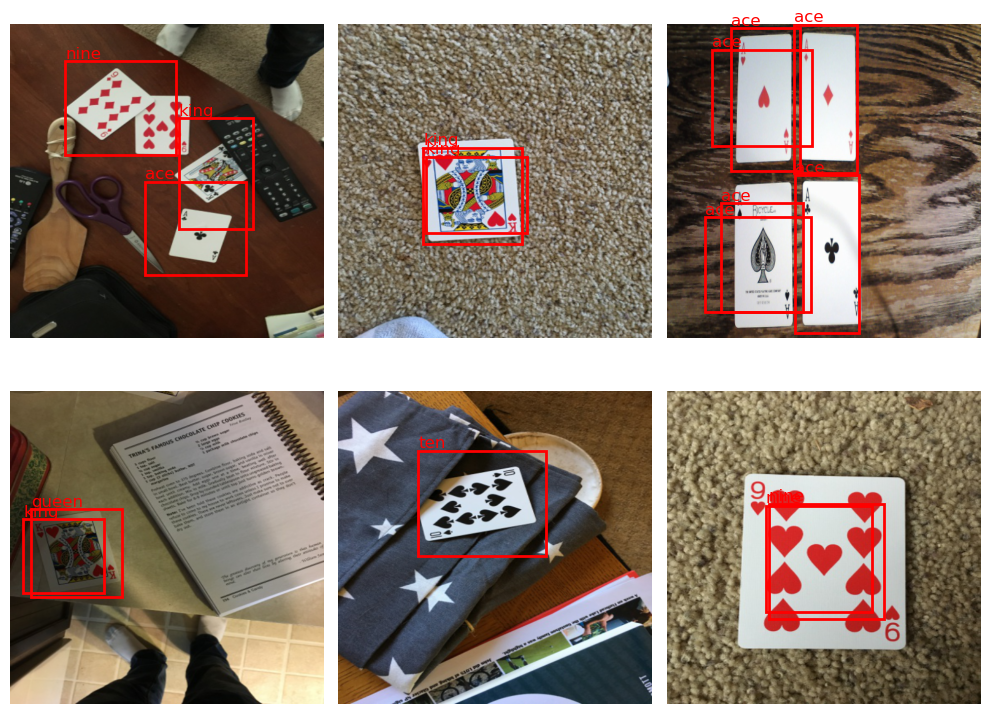

In [75]:
# Сделайте визуализацию. Поиграйтесь с threshold, скорее всего нужно понизить до ~0.1
# Декодируем предсказания (преобразуем выход модели в bboxes)
pred_boxes = decode_prediction(predicts, upsample=32, threshold=0.1)
# pred_boxes = decode_prediction(predicts, upsample=32, threshold=0.05)
# pred_boxes = decode_prediction(predicts, upsample=32, threshold=0.2)
# Получаем изображения из батча
images = batch["image"]

# Визуализируем
visualize(images, pred_boxes)
### YOUR CODE HERE ###

Результат сильно так себе, да? Есть множество вариантов улучшений, самый простой из которых это приделать к выходу [NMS](https://paperswithcode.com/method/non-maximum-suppression#:~:text=Non%20Maximum%20Suppression%20is%20a,below%20a%20given%20probability%20bound.). Если хочется, можно почитать про YOLO v1 [тут](https://arxiv.org/abs/1506.02640).

# Задача 5. 3.5 балла.

Займёмся более простыми вещами. Возьмем готовую архитектуру, обучим её на наших данных и посмотрим.

Для этого будем использовать YOLO v8 от ultralytics.

In [ ]:
#!pip install --user ultralytics

## Задача 5.1. 1.5 балла.

Чтобы дальше модель обучалась одной строкой, данные нужно переложить в правильный формат. Да-да, классика перекладывания JSON. Как правильно паковать можно посмотреть [тут](https://roboflow.com/formats/yolov8-pytorch-txt).

Если коротко:
* Есть .yaml, где живут пути к папкам с картинками, количество классов и их названия
* Есть папочки train valid (их поможем вам собрать), в них две подпапки:
    - Первая images, в ней лежат картинки
    - Вторая labels, в ней лежат файлы с названиями как у картинок, но вместо расширения картинок нужен .txt, внутри формат как описан на Roboflow


In [ ]:
# Делаем папочки
!rm -rf train
!rm -rf valid
!mkdir -p train/images train/labels valid/images valid/labels

Реализуйте функцию, которая принимает аннотации в изначальном формате, а возвращает их в нужном для YOLO v8. Это должен быть массив готовых строк, которые можно сразу забрасывать в файлик, добавив \n.

In [ ]:
def annotation2txt(bboxes, w_im, h_im):
    lines = []
    for xmin, ymin, xmax, ymax, class_id in bboxes:
        cx = (xmin + xmax) / 2 / w_im
        cy = (ymin + ymax) / 2 / h_im
        w = (xmax - xmin) / w_im
        h = (ymax - ymin) / h_im 
        lines.append(f"{class_id} {cx} {cy} {w} {h}")
    return lines

In [ ]:
# Копируем картиночки по папочкам и создаем txt файлики

for i in range(len(train_ds)):
    result = train_ds.__get_raw_item__(i)
    
    src_path = Path(result[0])
    filename = src_path.name  
    stem = src_path.stem     
    
    shutil.copyfile(str(src_path), f"./train/images/{filename}")
    
    h_im, w_im, ch = np.array(Image.open(str(src_path))).shape
    with open(f"./train/labels/{stem}.txt", "w", encoding="utf8") as f:
        f.write("\n".join(annotation2txt(result[1], w_im, h_im)))

for i in range(len(test_ds)):
    result = test_ds.__get_raw_item__(i)
    
    src_path = Path(result[0])
    filename = src_path.name
    stem = src_path.stem
    
    shutil.copyfile(str(src_path), f"./valid/images/{filename}")
    
    h_im, w_im, ch = np.array(Image.open(str(src_path))).shape
    with open(f"./valid/labels/{stem}.txt", "w", encoding="utf8") as f:
        f.write("\n".join(annotation2txt(result[1], w_im, h_im)))

In [ ]:
nc = 6 
names = ["king", "jack", "ace", "ten", "nine", "queen"]

with open("data.yaml", "w") as f:
    f.write(f"train: ../train/images\nval: ../valid/images\n\nnc: {nc}\nnames: {names}")

## Задание 5.2. 1.5 балла.

Обучите модель YOLO v8 самого маленького размера. Библиотека максимально friendly, от вас требуется написать две строчки. Модель нужно взять необученную!

Подсказка: подумайте зачем вам data.yaml и что такое yolov8n.yaml (не стесняйтесь гуглить)

In [16]:
import ultralytics

model = ultralytics.YOLO("yolov8n.pt")
model.train(data="data.yaml", epochs=15, imgsz=512)


### YOUR CODE HERE ###

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\anton\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.24  Python-3.10.18 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

2026/03/20 19:51:10 INFO mlflow.tracking.fluent: Experiment with name '/Shared/Ultralytics' does not exist. Creating a new experiment.


MLflow: logging run_id(ce82c4a787224aa997b776c13b1ddba0) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 512 train, 512 val
Using 8 dataloader workers
Logging results to C:\Users\anton\PycharmProjects\hse_hw\intro-to-ds\hw-3\runs\detect\train
Starting training for 15 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/15      1.32G     0.7052      3.336      1.054         25        512: 100% ━━━━━━━━━━━━ 21/21 3.4it/s 6.2s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.5it/s 0.4s0.8s
                   all         37         67    0.00715          1      0.269      0.234

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/15      1.53G     0.6712      2.409      1.018         11        512: 100% ━━━━━━━━━━━━ 21/21 10.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F5C56150F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

In [82]:
model

Detector(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64

## Задание 5.3. 0.5 балла.

Как-нибудь отрисуйте предсказания на валидационной выборке (хотя бы части из 5-10 картинок).

Здесь можно использовать костыли с параметром save=True у predict, потом прочитать их чем-нибудь, отрисовать матплотлибом. Есть варианты и получше. Дефолтный show будет пытаться показывать через opencv imshow, он в коллабе работать не будет.


image 1/37 c:\Users\anton\PycharmProjects\hse_hw\intro-to-ds\hw-3\valid\images\IMG_2385.JPG: 512x384 1 king, 21.0ms
image 2/37 c:\Users\anton\PycharmProjects\hse_hw\intro-to-ds\hw-3\valid\images\IMG_2389.JPG: 512x384 1 ace, 21.3ms
image 3/37 c:\Users\anton\PycharmProjects\hse_hw\intro-to-ds\hw-3\valid\images\IMG_2402.JPG: 512x384 1 queen, 16.3ms
image 4/37 c:\Users\anton\PycharmProjects\hse_hw\intro-to-ds\hw-3\valid\images\IMG_2418.JPG: 512x384 1 ace, 30.5ms
image 5/37 c:\Users\anton\PycharmProjects\hse_hw\intro-to-ds\hw-3\valid\images\IMG_2430.JPG: 512x384 1 king, 15.0ms
image 6/37 c:\Users\anton\PycharmProjects\hse_hw\intro-to-ds\hw-3\valid\images\IMG_2433.JPG: 512x384 1 jack, 1 queen, 21.7ms
image 7/37 c:\Users\anton\PycharmProjects\hse_hw\intro-to-ds\hw-3\valid\images\IMG_2437.JPG: 512x384 1 ten, 1 nine, 12.5ms
image 8/37 c:\Users\anton\PycharmProjects\hse_hw\intro-to-ds\hw-3\valid\images\IMG_2454.JPG: 512x384 1 ten, 1 nine, 9.2ms
image 9/37 c:\Users\anton\PycharmProjects\hse_hw\i

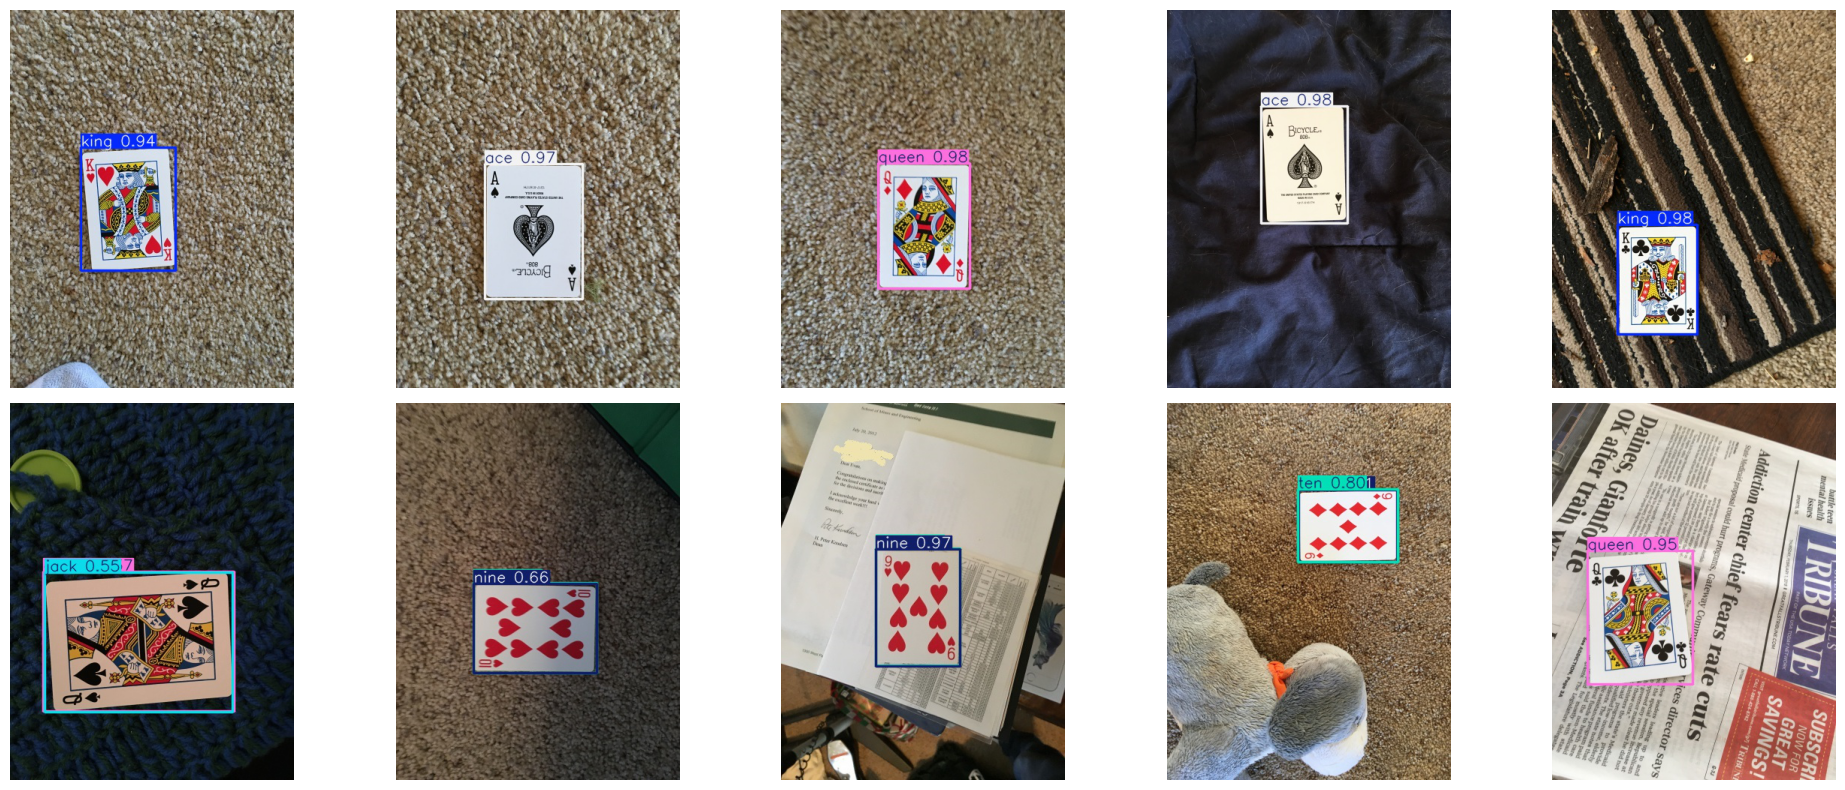

In [ ]:
### YOUR CODE HERE ###
import glob
from PIL import Image

results = model.predict(source="./valid/images", save=True, conf=0.1)

saved_images = sorted(glob.glob("runs/detect/predict/*.jpg"))[:10]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, img_path in enumerate(saved_images):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis("off")

plt.tight_layout()
plt.show()